## 1. Import Necessary Libraries

In [1]:
# Data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from ydata_profiling import ProfileReport
import os
%matplotlib inline

# Scikit-learn: Datasets, Model training, preprocessing, and evaluation
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

# Regression models from scikit-learn
from sklearn.linear_model import LinearRegression 
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.svm import LinearSVR  


## 2. Load and Explore data

In [ ]:
# # Option 1. Using Bunch (direct from sklearn)

# # Fetch the California housing dataset
# data = datasets.fetch_california_housing()

# # Access the data and target
# x = data.data
# y = data.target

# # Print the first few rows of data
# print(x[:5])
# print(y[:5])

# # Display the feature names
# print("\nFeature Names:")
# print(data.feature_names)

# # Display the target names
# print("\nTarget Names:")
# print(data.target_names)  

# # Display the description of the dataset
# print("\nDataset Description:")
# print(data.DESCR)


In [3]:
 # Option 2 : Using pandas (convert to DataFrame)

# Fetching the California housing dataset
california_housing_data = datasets.fetch_california_housing()

# Convert the data to a DataFrame
data = pd.DataFrame(california_housing_data.data, columns=california_housing_data.feature_names)

# Add the target variable to the DataFrame 
data['Target'] = california_housing_data.target

# Display the first few rows
print(data.head())


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0    8.33     41.00      6.98       1.02      322.00      2.56     37.88   
1    8.30     21.00      6.24       0.97     2401.00      2.11     37.86   
2    7.26     52.00      8.29       1.07      496.00      2.80     37.85   
3    5.64     52.00      5.82       1.07      558.00      2.55     37.85   
4    3.85     52.00      6.28       1.08      565.00      2.18     37.85   

   Longitude  Target  
0    -122.23    4.53  
1    -122.22    3.58  
2    -122.24    3.52  
3    -122.25    3.41  
4    -122.25    3.42  


In [6]:
# Save the DataFrame as a CSV file
data.to_csv('california_housing.csv', index=False)

# Print the absolute path of the saved file
print(os.path.abspath('california_housing.csv'))

C:\Users\Dell\california_housing.csv


In [7]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [8]:
# # ydata-profiling generates an in-depth report, helping us quickly understand, data distributions, and correlations.
# profile = ProfileReport(data, title = "california_housing_Report", explorative=True)
# profile.to_file("report_california_housing.html")
# print(os.path.abspath("report_california_housing_dataset.html"))

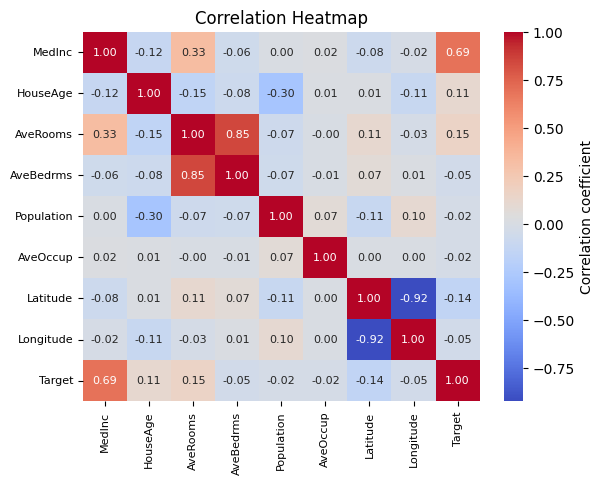

In [9]:
# correlation matrix helps identify relationships between features, how they interact, and avoid multicollinearity.
numeric_data = data.select_dtypes(include=['float64', 'int64'])

sns.heatmap(numeric_data.corr(), annot=True, 
             cmap="coolwarm", fmt=".2f", annot_kws={"size": 8}, 
             cbar_kws={'label': 'Correlation coefficient'})
plt.title("Correlation Heatmap")
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

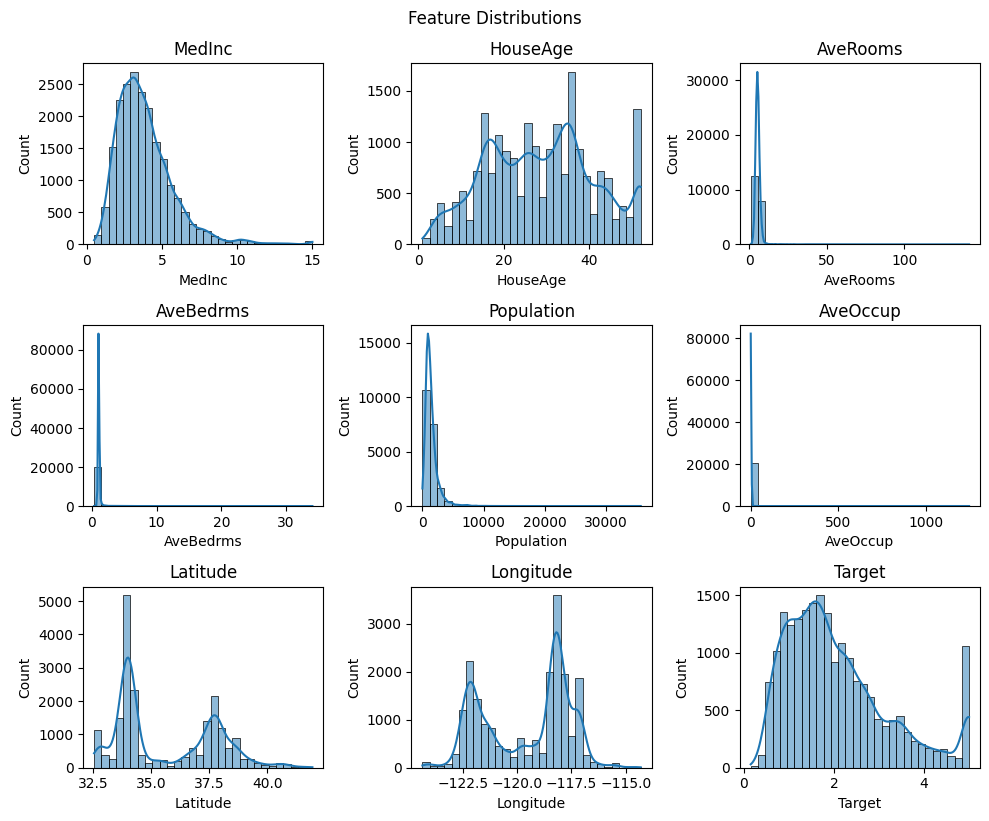

In [10]:
# Feature Distributions: Visualize numeric features to understand their distribution
# Helps identify skewness, outliers, and check normality for preprocessing decisions.

numeric_columns = data.select_dtypes(include=['number']).columns

# Create a grid for the plots (4 rows, 3 columns)
fig, axes = plt.subplots(3, 3, figsize=(10, 8))
# Flatten the grid to access each plot easily
axes = axes.flatten()
# Loop through each numeric column and create a histogram
for i, column in enumerate(numeric_columns):
    sns.histplot(data=data, x=column, kde=True, bins=30, ax=axes[i])  
    axes[i].set_title(f'{column}')  
plt.tight_layout()
plt.suptitle("Feature Distributions", y=1.02)  
plt.show()

In [11]:
# Skewness and kurtosis help evaluate the distribution of numerical features
# Skewness close to 0 suggests a symmetric distribution, 
# positive skew (>0) indicates a right tail,  
# negative skew (<0) indicates a left tail.

# Kurtosis values around 3 indicate a normal distribution. 
# Values > 3 suggest heavy tails (outliers), 
# while < 3 suggests light tails.

print("Skewness for numerical columns:")
print(data.select_dtypes(include=['number']).skew())

print("Kurtosis for numerical columns:")
print(data.select_dtypes(include=['number']).kurt())

Skewness for numerical columns:
MedInc        1.65
HouseAge      0.06
AveRooms     20.70
AveBedrms    31.32
Population    4.94
AveOccup     97.64
Latitude      0.47
Longitude    -0.30
Target        0.98
dtype: float64
Kurtosis for numerical columns:
MedInc           4.95
HouseAge        -0.80
AveRooms       879.35
AveBedrms     1636.71
Population      73.55
AveOccup     10651.01
Latitude        -1.12
Longitude       -1.33
Target           0.33
dtype: float64


Number of outliers in each column: 
MedInc         681
HouseAge         0
AveRooms       511
AveBedrms     1424
Population    1196
AveOccup       711
Latitude         0
Longitude        0
Target        1071
dtype: int64


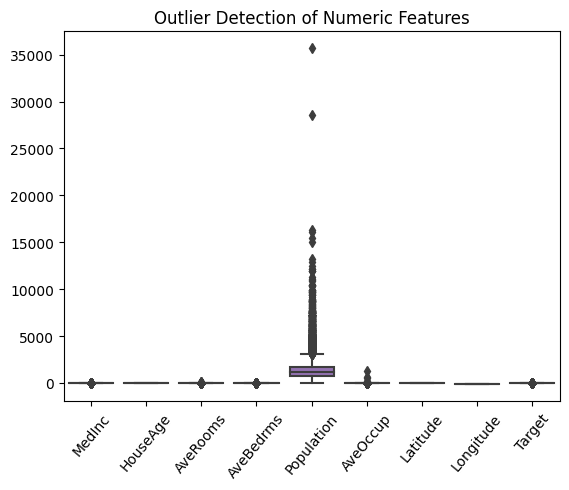

In [12]:
# Outlier Detection helps prevent extreme values from distorting statistical analysis and model predictions
numeric_df = data.select_dtypes(include=['float64', 'int64'])
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).sum()
print(f"Number of outliers in each column: \n{outliers}")

# Visualize the distribution of outliers 
sns.boxplot(data=numeric_df)
plt.title("Outlier Detection of Numeric Features")
plt.xticks(rotation=50)
plt.show()

## 3. Splitting Data into Training and Test Sets

In [14]:
# Split features (x) and target (y)
x = data.drop(columns=['Target'])  # Features
y = data['Target']                 # Target variable

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Print shapes of the splits
print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_test: {x_test.shape}, y_test: {y_test.shape}")

# Preview the training data
print(x_train.head())
print(x_train.dtypes)

x_train: (16512, 8), y_train: (16512,)
x_test: (4128, 8), y_test: (4128,)
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
14196    3.26     33.00      5.02       1.01     2300.00      3.69     32.71   
8267     3.81     49.00      4.47       1.04     1314.00      1.74     33.77   
17445    4.16      4.00      5.65       0.99      915.00      2.72     34.66   
14265    1.94     36.00      4.00       1.03     1418.00      3.99     32.69   
2271     3.55     43.00      6.27       1.13      874.00      2.30     36.78   

       Longitude  
14196    -117.03  
8267     -118.16  
17445    -120.48  
14265    -117.11  
2271     -119.80  
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
dtype: object


## 4. Data Preprocessing

In [15]:
# Handle Outliers by using IQR
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
numerical_columns = x_train.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_columns:
    cap_outliers(x_train, col)
    cap_outliers(x_test, col)
# Verify the changes
print(f"Preprocessed Training set:\n{x_train.head()}")

Preprocessed Training set:
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
14196    3.26     33.00      5.02       1.01     2300.00      3.69     32.71   
8267     3.81     49.00      4.47       1.04     1314.00      1.74     33.77   
17445    4.16      4.00      5.65       0.99      915.00      2.72     34.66   
14265    1.94     36.00      4.00       1.03     1418.00      3.99     32.69   
2271     3.55     43.00      6.27       1.13      874.00      2.30     36.78   

       Longitude  
14196    -117.03  
8267     -118.16  
17445    -120.48  
14265    -117.11  
2271     -119.80  


In [16]:
scaler_robust = RobustScaler()
numerical_columns = x_train.select_dtypes(include=['float64', 'int64']).columns
x_train[numerical_columns] = scaler_robust.fit_transform(x_train[numerical_columns])
x_test[numerical_columns] = scaler_robust.transform(x_test[numerical_columns])
# Verify the changes
print(f"Preprocessed Training set:\n{x_train.head()}")

Preprocessed Training set:
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
14196   -0.13      0.21     -0.14      -0.46        1.21      1.03     -0.41   
8267     0.12      1.05     -0.47      -0.09        0.16     -1.27     -0.13   
17445    0.28     -1.32      0.25      -0.68       -0.27     -0.11      0.11   
14265   -0.73      0.37     -0.77      -0.16        0.27      1.38     -0.41   
2271     0.00      0.74      0.64       0.90       -0.31     -0.61      0.66   

       Longitude  
14196       0.39  
8267        0.09  
17445      -0.52  
14265       0.37  
2271       -0.34  


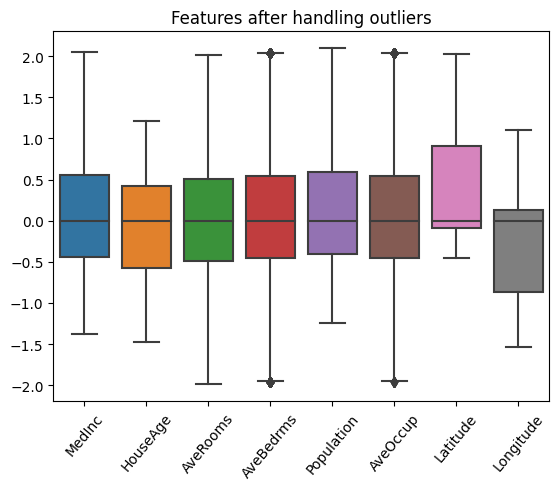

In [17]:
# Plot features after handling outliers
sns.boxplot(data=x_train[numerical_columns])
plt.title("Features after handling outliers")
plt.xticks(rotation=50)
plt.show()

## 5. Model Fitting, Test, Evaluation  

In [18]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train)
accuracy = model.score(x_test, y_test)
print(f"Accuracy based on test dataset : {accuracy:.2f}")

Accuracy based on test dataset : 0.79


In [19]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train)
y_predict = model.predict(x_test)
mse = mean_squared_error(y_test, y_predict)
mae = mean_absolute_error(y_test, y_predict)
r2 = r2_score(y_test, y_predict)

print(f"{model}. Mean Squared Error: {mse:.2f}")
print(f"{model}. mean_absolute_error: {mae:.2f}")
print(f"{model}. r2_score: {r2:.2f}")


RandomForestRegressor(random_state=42). Mean Squared Error: 0.27
RandomForestRegressor(random_state=42). mean_absolute_error: 0.34
RandomForestRegressor(random_state=42). r2_score: 0.79


# 6. Evaluation models

In [20]:
model = GradientBoostingRegressor()
model.fit(x_train, y_train)
y_predict = model.predict(x_test)
mse = mean_squared_error(y_test, y_predict)
mae = mean_absolute_error(y_test, y_predict)
r2 = r2_score(y_test, y_predict)

print(f"{model}. Mean Squared Error: {mse:.2f}")
print(f"{model}. mean_absolute_error: {mae:.2f}")
print(f"{model}. r2_score: {r2:.2f}")

GradientBoostingRegressor(). Mean Squared Error: 0.30
GradientBoostingRegressor(). mean_absolute_error: 0.38
GradientBoostingRegressor(). r2_score: 0.77


In [21]:

models = {
    'ExtraTreesRegressor': ExtraTreesRegressor(random_state=42),
    'LinearRegression': LinearRegression(),
    'LinearSVR': LinearSVR()  
}

# Train and evaluate the models
for name, model in models.items():
    model.fit(x_train, y_train)  
    y_pred = model.predict(x_test)      
  
    mse = mean_squared_error(y_test, y_pred)  
    mae = mean_absolute_error(y_test, y_pred)  
    r2 = r2_score(y_test, y_pred)  

    print(f"{name}. Mean Squared Error: {mse:.2f}")
    print(f"{name}. Mean Absolute Error: {mae:.2f}")
    print(f"{name}. R2 Score: {r2:.2f}")
    print('-'*50)


ExtraTreesRegressor. Mean Squared Error: 0.29
ExtraTreesRegressor. Mean Absolute Error: 0.36
ExtraTreesRegressor. R2 Score: 0.78
--------------------------------------------------
LinearRegression. Mean Squared Error: 0.47
LinearRegression. Mean Absolute Error: 0.51
LinearRegression. R2 Score: 0.64
--------------------------------------------------
LinearSVR. Mean Squared Error: 0.48
LinearSVR. Mean Absolute Error: 0.50
LinearSVR. R2 Score: 0.63
--------------------------------------------------
